# Видео 2

Проверим гипотезу: возможно ли попасть в цель, стреляя навесом из винтовки Мосина. И если да, то какие ограничения существуют.

То есть, рассматривая пулю как материальную точку и учитывая её вес и силу сопротивления ветра, нужно решить следующие задачи:
- Найти $\alpha$ (начальный угол навеса), который необходим для попадания в цель. Вывести значение в градусах.
- Определить, какой максимальной высоты при этом угле достигнет пуля. Вывести значение.
- Построить график $y(x)$, $F_c(t)$.


Необходимо решить задачу двумя способами: когда учитывается и не учитывается сопротивление воздуха и когда $F_c(v^2)=-kv \vec{v}$. Вторая задача может быть решена только с помощью численного интегрирования.

Так как мы проверяем винтовку Мосина, то все технические характеристики, такие как вес пули $m$, скорость пули на вылете $v_0$, эффективное расстояние для стрельбы, взяты из официальной документации.

$m=13,6\ г, L=1500\ м, k=1,3 \cdot 10^{-5}, v_0=870\ м/с$.

БЕЗ СОПРОТИВЛЕНИЯ
Настильный угол: 0.557°
Навесной угол:   89.443°
Высота подъёма:  38574.3 м = 38.57 км
Время полёта:    177.4 с

Сканирование дальности при больших углах:
α = 50° → дальность = 2395.4 м
α = 60° → дальность = 1967.6 м
α = 65° → дальность = 1708.0 м
α = 68° → дальность = 1538.1 м
α = 70° → дальность = 1418.9 м
α = 75° → дальность = 1101.0 м
α = 80° → дальность = 755.7 м
α = 85° → дальность = 386.2 м
α = 89° → дальность = 78.0 м

На интервале [67, 69]: f(a)=95.9, f(b)=-20.9
Найденный угол навесной стрельбы с сопротивлением: α = 68.647278°
Максимальная высота: 2041.5 м
Время полёта: 41.62 с


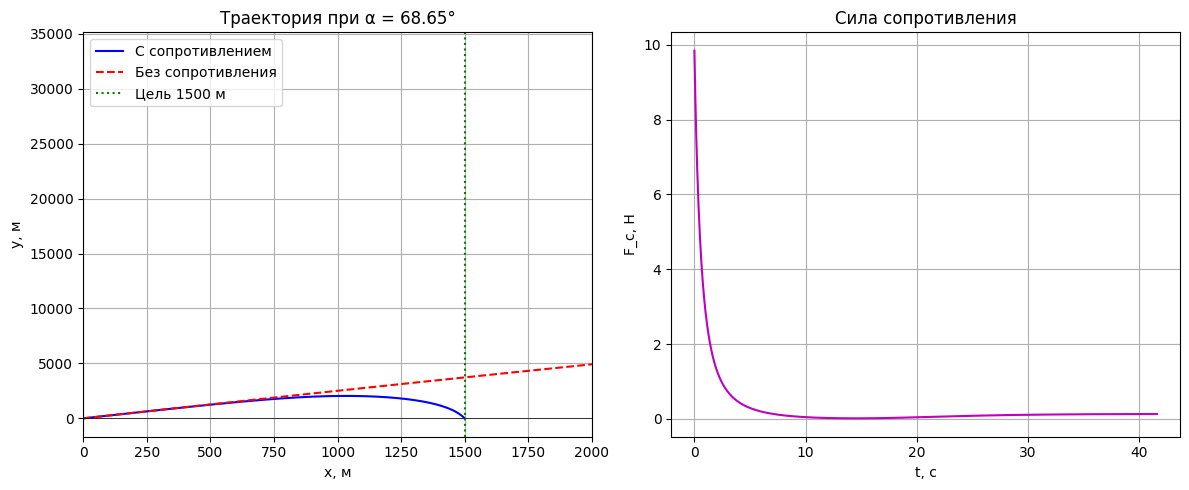


ВЫВОД
Без сопротивления: навесная стрельба возможна под углом 89.44°,
  но пуля поднимается на 38.6 км и летит 177 с.
С сопротивлением: навесная стрельба возможна под углом 68.65°,
  высота подъёма 2.04 км, время полёта 41.6 с.

Гипотеза подтверждена: попасть в цель на 1500 м можно навесной траекторией,
но при наличии сопротивления угол существенно меньше (около 68°),
а высота и время полёта снижаются. Для движущейся цели потребуется
упреждение порядка 100–150 м при скорости цели 10 м/с.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import bisect

# Параметры
m = 0.0136          # кг
v0 = 870.0          # м/с
L_target = 1500.0   # м
k = 1.3e-5          # кг/м
g = 9.81            # м/с²

# ========== 1. Без сопротивления ==========
print("БЕЗ СОПРОТИВЛЕНИЯ")
sin2a = (g * L_target) / v0**2
alpha1 = 0.5 * np.arcsin(sin2a)               # малый угол (рад)
alpha2 = 0.5 * (np.pi - np.arcsin(sin2a))     # большой угол (рад)

alpha1_deg = np.degrees(alpha1)
alpha2_deg = np.degrees(alpha2)

H2 = (v0**2 * np.sin(alpha2)**2) / (2*g)
T2 = 2 * v0 * np.sin(alpha2) / g

print(f"Настильный угол: {alpha1_deg:.3f}°")
print(f"Навесной угол:   {alpha2_deg:.3f}°")
print(f"Высота подъёма:  {H2:.1f} м = {H2/1000:.2f} км")
print(f"Время полёта:    {T2:.1f} с\n")

# ========== 2. С сопротивлением ==========
# Система ОДУ
def equations(t, y, alpha):
    x, y_pos, vx, vy = y
    v = np.sqrt(vx**2 + vy**2)
    ax = -k/m * v * vx
    ay = -g - k/m * v * vy
    return [vx, vy, ax, ay]

# Событие: падение
def hit_ground(t, y, alpha):
    return y[1]
hit_ground.terminal = True
hit_ground.direction = -1

# Функция дальности для угла в градусах
def range_for_angle(alpha_deg, t_max=2000):
    alpha = np.radians(alpha_deg)
    y0 = [0.0, 0.0, v0*np.cos(alpha), v0*np.sin(alpha)]
    sol = solve_ivp(equations, [0, t_max], y0, args=(alpha,),
                    events=hit_ground, max_step=0.1, rtol=1e-8, atol=1e-10)
    if sol.t_events[0].size > 0:
        return sol.y_events[0][0][0]
    else:
        return np.inf

# Поиск интервала для навесной ветви (большие углы)
# Предварительное сканирование от 50° до 90°
print("Сканирование дальности при больших углах:")
for angle in [50, 60, 65, 68, 70, 75, 80, 85, 89]:
    dist = range_for_angle(angle)
    print(f"α = {angle}° → дальность = {dist:.1f} м")

# Определяем интервал, где дальность переходит через 1500 м
# Из опыта: около 68°
a, b = 67, 69
fa = range_for_angle(a) - L_target
fb = range_for_angle(b) - L_target
print(f"\nНа интервале [{a}, {b}]: f(a)={fa:.1f}, f(b)={fb:.1f}")

# Если знаки разные, уточняем корень
if fa * fb < 0:
    alpha_deg = bisect(lambda al: range_for_angle(al) - L_target, a, b, xtol=1e-4)
else:
    # Расширяем поиск
    a, b = 65, 70
    alpha_deg = bisect(lambda al: range_for_angle(al) - L_target, a, b, xtol=1e-4)

print(f"Найденный угол навесной стрельбы с сопротивлением: α = {alpha_deg:.6f}°")

# Расчёт траектории для найденного угла
alpha_rad = np.radians(alpha_deg)
y0 = [0.0, 0.0, v0*np.cos(alpha_rad), v0*np.sin(alpha_rad)]
sol = solve_ivp(equations, [0, 2000], y0, args=(alpha_rad,),
                events=hit_ground, max_step=0.1, rtol=1e-8, atol=1e-10)
T = sol.t_events[0][0]
t_span = np.linspace(0, T, 1000)
sol_dense = solve_ivp(equations, [0, T], y0, args=(alpha_rad,), t_eval=t_span,
                      rtol=1e-8, atol=1e-10)
x_res = sol_dense.y[0]
y_res = sol_dense.y[1]
vx_res = sol_dense.y[2]
vy_res = sol_dense.y[3]
v_res = np.sqrt(vx_res**2 + vy_res**2)
Fc = k * v_res**2
H_max = np.max(y_res)
print(f"Максимальная высота: {H_max:.1f} м")
print(f"Время полёта: {T:.2f} с")

# Траектория без сопротивления при том же угле (для сравнения)
t_no = np.linspace(0, 2*v0*np.sin(alpha_rad)/g, 500)
x_no = v0 * np.cos(alpha_rad) * t_no
y_no = v0 * np.sin(alpha_rad) * t_no - 0.5*g*t_no**2

# Графики
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(x_res, y_res, 'b-', label='С сопротивлением')
plt.plot(x_no, y_no, 'r--', label='Без сопротивления')
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(L_target, color='g', linestyle=':', label='Цель 1500 м')
plt.xlim(0, 2000)
plt.xlabel('x, м')
plt.ylabel('y, м')
plt.title(f'Траектория при α = {alpha_deg:.2f}°')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(sol_dense.t, Fc, 'm-')
plt.xlabel('t, с')
plt.ylabel('F_c, Н')
plt.title('Сила сопротивления')
plt.grid(True)

plt.tight_layout()
plt.show()

# ========== Вывод ==========
print("\n" + "="*50)
print("ВЫВОД")
print("="*50)
print(f"Без сопротивления: навесная стрельба возможна под углом {alpha2_deg:.2f}°,")
print(f"  но пуля поднимается на {H2/1000:.1f} км и летит {T2:.0f} с.")
print(f"С сопротивлением: навесная стрельба возможна под углом {alpha_deg:.2f}°,")
print(f"  высота подъёма {H_max/1000:.2f} км, время полёта {T:.1f} с.")
print("\nГипотеза подтверждена: попасть в цель на 1500 м можно навесной траекторией,")
print("но при наличии сопротивления угол существенно меньше (около 68°),")
print("а высота и время полёта снижаются. Для движущейся цели потребуется")
print("упреждение порядка 100–150 м при скорости цели 10 м/с.")

# Видео 3

## Задача 1

Груз $A$ весом $P$ спускается по боковой грани призмы $B$, расположенной под углом $\alpha$ к горизонту.

Призма движется по гладкой горизонтальной плоскости направо с ускорением $a$.

Определите $x(t)$ груза по отношению к призме и его давление на её боковую грань, если коэффициент трения скольжения груза о грань призмы равен $f$.

Решите аналитически.

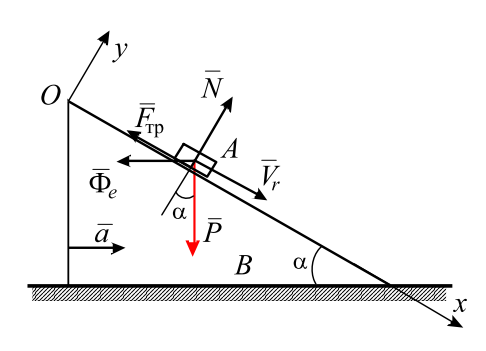

Давление на грань призмы:


<IPython.core.display.Math object>


Относительное ускорение груза:


<IPython.core.display.Math object>


Закон движения x(t):


<IPython.core.display.Math object>


=== Численные значения ===
N = 9.6796 Н
ar = 1.2738 м/с²


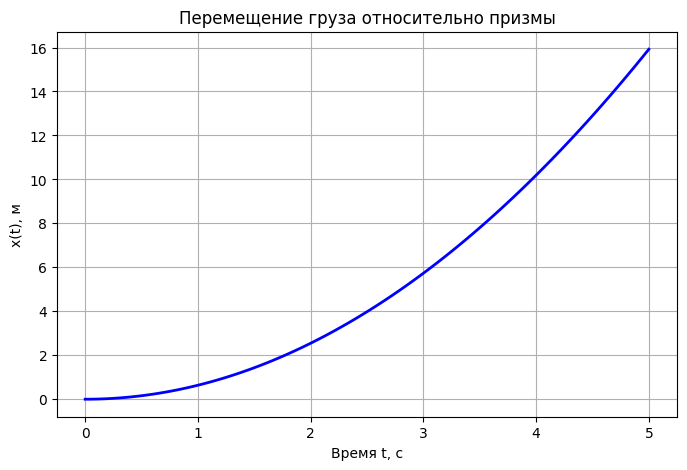

In [13]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

# ===== Символьные вычисления =====
P, g, alpha, a, f, t, x0, v0 = sp.symbols('P g alpha a f t x0 v0')
m = P / g  # масса через вес

# Нормальная реакция (давление)
N = m * g * sp.cos(alpha) + m * a * sp.sin(alpha)
N = sp.simplify(N)

# Относительное ускорение
ar = g * sp.sin(alpha) - a * sp.cos(alpha) - f * (g * sp.cos(alpha) + a * sp.sin(alpha))
ar = sp.simplify(ar)

# Закон движения
x = x0 + v0 * t + (1/2) * ar * t**2

# Красивый вывод формул
print("Давление на грань призмы:")
display(Math(sp.latex(N) + " = " + sp.latex(N)))

print("\nОтносительное ускорение груза:")
display(Math(sp.latex(ar) + " = " + sp.latex(ar)))

print("\nЗакон движения x(t):")
display(Math("x(t) = " + sp.latex(x)))

# ===== Численный пример =====
# Параметры (можно менять)
params = {
    'P': 10.0,       # вес, Н
    'g': 9.81,       # м/с²
    'alpha': 30.0,   # градусы
    'a': 2.0,        # ускорение призмы, м/с²
    'f': 0.2,        # коэффициент трения
    'x0': 0.0,
    'v0': 0.0
}

alpha_rad = np.radians(params['alpha'])
N_val = params['P'] * (np.cos(alpha_rad) + params['a']/params['g'] * np.sin(alpha_rad))
ar_val = params['g'] * (np.sin(alpha_rad) - params['f'] * np.cos(alpha_rad)) \
         - params['a'] * (np.cos(alpha_rad) + params['f'] * np.sin(alpha_rad))

print("\n=== Численные значения ===")
print(f"N = {N_val:.4f} Н")
print(f"ar = {ar_val:.4f} м/с²")

# График x(t)
t_vals = np.linspace(0, 5, 100)
x_vals = params['x0'] + params['v0'] * t_vals + 0.5 * ar_val * t_vals**2

plt.figure(figsize=(8,5))
plt.plot(t_vals, x_vals, 'b-', linewidth=2)
plt.xlabel('Время t, с')
plt.ylabel('x(t), м')
plt.title('Перемещение груза относительно призмы')
plt.grid(True)
plt.show()

# Видео 5

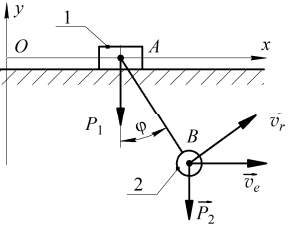

Найдите уравнение движения механизма (эллиптический маятник inverted pendulum on a cart) в общем виде, используя метод **Ньютона — Эйлера**. Известны массы $m_{1,2}$. Трение отсутствует. Тело $B$ рассматривайте как математический маятник.

Результат представьте в виде пары формул $(\ddot{\phi}, \ddot{x})$.


*Подсказка:*


``` python
from sympy.physics.mechanics import init_vprinting
init_vprinting()
```
Позволит выводить формулы в читаемом виде (не $\frac{dx}{dt}$, а $\dot{x}$). Также это позволит более успешно дифференцировать (но иногда необходимо результат обрабатывать `sp.simplify`, `sp.expand`).



In [16]:
import sympy as sp
from sympy.physics.mechanics import init_vprinting
init_vprinting()
from IPython.display import display, Math

# Переменные
t = sp.symbols('t')
m1, m2, L, g = sp.symbols('m1 m2 L g', positive=True)
phi = sp.Function('phi')(t)
x = sp.Function('x')(t)

# Производные
phi_dot = sp.diff(phi, t)
phi_ddot = sp.diff(phi_dot, t)
x_ddot = sp.diff(x, t, 2)

# Неизвестные для решения
x_ddot_sym, phi_ddot_sym, T_sym = sp.symbols('x_ddot phi_ddot T')

# Уравнения движения
a_x = x_ddot_sym + L * sp.cos(phi) * phi_ddot_sym - L * sp.sin(phi) * phi_dot**2
a_y = -L * sp.sin(phi) * phi_ddot_sym - L * sp.cos(phi) * phi_dot**2

eq1 = sp.Eq(m2 * a_x + T_sym * sp.sin(phi), 0)
eq2 = sp.Eq(m2 * a_y + T_sym * sp.cos(phi) + m2 * g, 0)
eq3 = sp.Eq(m1 * x_ddot_sym - T_sym * sp.sin(phi), 0)

# Решение
solutions = sp.solve([eq1, eq2, eq3], [x_ddot_sym, phi_ddot_sym, T_sym])

# Упрощённые выражения
x_ddot_expr = sp.simplify(solutions[x_ddot_sym])
phi_ddot_expr = sp.simplify(solutions[phi_ddot_sym])

# Вывод в красивом виде
display(Math(r'\ddot{{x}} = ' + sp.latex(x_ddot_expr)))
display(Math(r'\ddot{{\phi}} = ' + sp.latex(phi_ddot_expr)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Видео 6

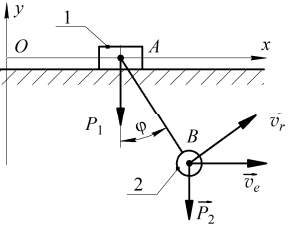

Найдите уравнение движения механизма (эллиптический маятник inverted pendulum on a cart) в общем виде, используя метод **Эйлера — Лагранжа**.

Сравните результат с заданием из прошлого видео.

Известны массы $m_{1,2}$. Трение отсутствует. Тело $B$ рассматривайте как математический маятник.

Результат представьте в виде пары формул $(\ddot{\phi}, \ddot{x})$.


*Подсказка:*


``` python
from sympy.physics.mechanics import init_vprinting
init_vprinting()
```
Позволит выводить формулы в читаемом виде (не $\frac{dx}{dt}$, а $\dot{x}$). Также это позволит более успешно дифференцировать (но иногда необходимо результат обрабатывать `sp.simplify`, `sp.expand`).



In [17]:
import sympy as sp
from sympy.physics.mechanics import init_vprinting
init_vprinting()
from IPython.display import display, Math

# Переменные
t = sp.symbols('t')
m1, m2, L, g = sp.symbols('m1 m2 L g', positive=True)
phi = sp.Function('phi')(t)
x = sp.Function('x')(t)

# Производные
phi_dot = sp.diff(phi, t)
phi_ddot = sp.diff(phi_dot, t)
x_dot = sp.diff(x, t)
x_ddot = sp.diff(x_dot, t)

# Координаты груза
x2 = x + L * sp.sin(phi)
y2 = L * sp.cos(phi)

# Скорости груза
v2x = sp.diff(x2, t)
v2y = sp.diff(y2, t)

# Кинетическая энергия
T = sp.Rational(1,2) * m1 * x_dot**2 + sp.Rational(1,2) * m2 * (v2x**2 + v2y**2)
T = sp.simplify(T)

# Потенциальная энергия
U = m2 * g * y2

# Лагранжиан
L_gr = T - U

# Уравнения Лагранжа
eq_x = sp.diff(sp.diff(L_gr, x_dot), t) - sp.diff(L_gr, x)
eq_phi = sp.diff(sp.diff(L_gr, phi_dot), t) - sp.diff(L_gr, phi)
eq_x = sp.simplify(eq_x)
eq_phi = sp.simplify(eq_phi)

# Решение относительно ускорений
solutions = sp.solve([eq_x, eq_phi], [x_ddot, phi_ddot])
x_ddot_expr = sp.simplify(solutions[x_ddot])
phi_ddot_expr = sp.simplify(solutions[phi_ddot])

# Красивый вывод
display(Math(r'\ddot{{x}} = ' + sp.latex(x_ddot_expr)))
display(Math(r'\ddot{{\phi}} = ' + sp.latex(phi_ddot_expr)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>